In [1]:
import pandas as pd

In [2]:
ton_iot_dataset = pd.read_csv("train_test_network.csv")
simulation_dataset = pd.read_csv("dataset_training_iot.csv")
testbed_dataset = pd.read_csv("new_dataset_training_iot.csv")

print(f"TON-IoT loaded   : {ton_iot_dataset.shape}")
print(f"Simulation loaded: {simulation_dataset.shape}")
print(f"Testbed loaded   : {testbed_dataset.shape}")

TON-IoT loaded   : (211043, 44)
Simulation loaded: (36100, 47)
Testbed loaded   : (604581, 43)


In [3]:
for name, df in [("TON-IoT", ton_iot_dataset), ("Simulation", simulation_dataset), ("Testbed", testbed_dataset)]:
    print(f"\n--- {name} ---")
    print(df['label'].value_counts())
    print(df['type'].value_counts())


--- TON-IoT ---
label
1    161043
0     50000
Name: count, dtype: int64
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

--- Simulation ---
label
1    30986
0     5114
Name: count, dtype: int64
type
injection    5769
normal       5114
ddos         5094
mitm         5086
password     5037
dos          5000
scanning     5000
Name: count, dtype: int64

--- Testbed ---
label
0    378987
1    225594
Name: count, dtype: int64
type
normal       378987
injection     90795
dos           45289
password      32627
ddos          21456
scanning      19998
mitm          15429
Name: count, dtype: int64


In [4]:
for df in [ton_iot_dataset, simulation_dataset, testbed_dataset]:
    df.replace("-", "n/a", inplace=True)
    df.drop_duplicates(inplace=True)

print(f"TON-IoT after dedup   : {ton_iot_dataset.shape}")
print(f"Simulation after dedup: {simulation_dataset.shape}")
print(f"Testbed after dedup   : {testbed_dataset.shape}")

TON-IoT after dedup   : (190474, 44)
Simulation after dedup: (13104, 47)
Testbed after dedup   : (197022, 43)


In [5]:
for name, df in [("TON-IoT", ton_iot_dataset), ("Simulation", simulation_dataset), ("Testbed", testbed_dataset)]:
    print(f"\n--- {name} ---")
    print(df['label'].value_counts())
    print(df['type'].value_counts())


--- TON-IoT ---
label
1    148434
0     42040
Name: count, dtype: int64
type
normal        42040
scanning      20000
ddos          19993
injection     19964
password      19861
dos           18992
backdoor      18711
xss           15137
ransomware    14735
mitm           1041
Name: count, dtype: int64

--- Simulation ---
label
1    12917
0      187
Name: count, dtype: int64
type
dos          4985
scanning     4613
injection    2861
ddos          195
normal        187
password      132
mitm          131
Name: count, dtype: int64

--- Testbed ---
label
1    136620
0     60402
Name: count, dtype: int64
type
injection    90582
normal       60402
password     32619
mitm         10380
ddos          1430
dos           1330
scanning       279
Name: count, dtype: int64


In [6]:
DROP_COLS = ['src_ip', 'dst_ip', 'src_port', 'dst_port']

def drop_meta(df):
    return df.drop(columns=[c for c in DROP_COLS if c in df.columns])

ton_iot_dataset = drop_meta(ton_iot_dataset)
simulation_dataset = drop_meta(simulation_dataset)
testbed_dataset = drop_meta(testbed_dataset)

In [7]:
all_columns = sorted(
    set(ton_iot_dataset.columns) |
    set(simulation_dataset.columns) |
    set(testbed_dataset.columns)
)

def realign_columns(df, columns):
    for c in columns:
        if c not in df.columns:
            df[c] = 'n/a'
    return df[columns]

ton_iot_dataset    = realign_columns(ton_iot_dataset,    all_columns)
simulation_dataset = realign_columns(simulation_dataset, all_columns)
testbed_dataset    = realign_columns(testbed_dataset,    all_columns)

print(f"All datasets realigned to {len(all_columns)} columns.")

All datasets realigned to 49 columns.


In [8]:
binary_columns = ["dns_query",
                  "ssl_version", "ssl_cipher", "ssl_subject", "ssl_issuer",
                  "http_uri", "http_user_agent", "http_orig_mime_types", "http_resp_mime_types",
                  "weird_name", "history", "mqtt_topic", "mqtt_qos",
                  ]

dataset_sources = {
                    "ton_iot": ton_iot_dataset,
                    "simulation": simulation_dataset,
                    "testbed": testbed_dataset,
                }

combined_dataset = pd.concat([df.assign(source=name) for name, df in dataset_sources.items()],ignore_index=True,)

dataset_counts = combined_dataset["source"].value_counts().to_dict()
print(dataset_counts)

{'testbed': 197022, 'ton_iot': 190474, 'simulation': 13104}


In [9]:
#find categorical columns not in binary_columns
categorical_columns = [c for c in combined_dataset.columns if combined_dataset[c].dtype == "object" and c not in binary_columns and c != "source"]
print(f"Categorical columns: {categorical_columns}")

#drop type column since it is redundant with label
combined_dataset.drop(columns=["type"], inplace=True)
categorical_columns.remove("type")

for col in categorical_columns + binary_columns:
    combined_dataset[col] = combined_dataset[col].astype('category')

Categorical columns: ['conn_state', 'dns_AA', 'dns_RA', 'dns_RD', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_rejected', 'http_method', 'http_request_body_len', 'http_response_body_len', 'http_trans_depth', 'http_version', 'mqtt_from_client', 'mqtt_operation', 'mqtt_payload_len', 'mqtt_retain', 'mqtt_status', 'mqtt_topic_len', 'proto', 'service', 'ssl_established', 'ssl_resumed', 'type', 'weird_addl', 'weird_notice']


In [10]:
combined_dataset = pd.get_dummies(combined_dataset, columns=categorical_columns, sparse=False)

combined_dataset.head()

,dns_query,dst_bytes,dst_ip_bytes,dst_pkts,duration,history,http_orig_mime_types,http_resp_mime_types,http_status_code,http_uri,...,ssl_established_T,ssl_established_n/a,ssl_resumed_F,ssl_resumed_T,ssl_resumed_n/a,weird_addl_46,weird_addl_48,weird_addl_n/a,weird_notice_F,weird_notice_n/a
0,n/a,2592.0,3832.0,31.0,290.371539,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
1,n/a,0.0,40.0,1.0,0.000102,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
2,n/a,0.0,40.0,1.0,0.000148,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
3,n/a,0.0,40.0,1.0,0.000113,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
4,n/a,0.0,40.0,1.0,0.000130,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True


In [11]:
for col in binary_columns:
    combined_dataset[col] = (combined_dataset[col] != 'n/a').astype(int)

combined_dataset.head()

,dns_query,dst_bytes,dst_ip_bytes,dst_pkts,duration,history,http_orig_mime_types,http_resp_mime_types,http_status_code,http_uri,...,ssl_established_T,ssl_established_n/a,ssl_resumed_F,ssl_resumed_T,ssl_resumed_n/a,weird_addl_46,weird_addl_48,weird_addl_n/a,weird_notice_F,weird_notice_n/a
0,0,2592.0,3832.0,31.0,290.371539,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
1,0,0.0,40.0,1.0,0.000102,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
2,0,0.0,40.0,1.0,0.000148,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
3,0,0.0,40.0,1.0,0.000113,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
4,0,0.0,40.0,1.0,0.000130,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True


In [12]:
ton_iot_dataset    = combined_dataset[combined_dataset["source"] == "ton_iot"].drop(columns=["source"])
simulation_dataset = combined_dataset[combined_dataset["source"] == "simulation"].drop(columns=["source"])
testbed_dataset    = combined_dataset[combined_dataset["source"] == "testbed"].drop(columns=["source"])

print(f"TON-IoT final shape   : {ton_iot_dataset.shape}")
print(f"Simulation final shape: {simulation_dataset.shape}")
print(f"Testbed final shape   : {testbed_dataset.shape}")

TON-IoT final shape   : (190474, 300)
Simulation final shape: (13104, 300)
Testbed final shape   : (197022, 300)


In [13]:
from sklearn.model_selection import train_test_split
testbed_train, testbed_inference = train_test_split(testbed_dataset, test_size=0.5, random_state=42)

print(f"Testbed train shape   : {testbed_train.shape}")
print(f"Testbed inference shape   : {testbed_inference.shape}")

Testbed train shape   : (98511, 300)
Testbed inference shape   : (98511, 300)


In [14]:
train_dataset = pd.concat([ton_iot_dataset, simulation_dataset, testbed_train], ignore_index=True)

In [15]:
#determine amount of missing values in each column of train_dataset
missing_values = train_dataset.isnull().sum()

print(missing_values[missing_values > 0])

#get indices of rows with missing values
missing_indices = train_dataset[train_dataset.isnull().any(axis=1)].index
print(len(missing_indices))

#remove rows with missing values
train_dataset.drop(index=missing_indices, inplace=True)

print(f"Train dataset shape after removing missing values: {train_dataset.shape}")

dst_bytes       1380
dst_ip_bytes    1380
dst_pkts        1380
duration        1380
missed_bytes    1380
src_bytes       1380
src_ip_bytes    1380
src_pkts        1380
dtype: int64
1380
Train dataset shape after removing missing values: (300709, 300)


In [16]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(train_dataset.drop(columns=["label"]), train_dataset["label"])

print(f"Train dataset before SMOTE: {train_dataset.drop(columns=['label']).shape}, {train_dataset['label'].shape}")
print(f"Train dataset after SMOTE: {X_train.shape}, {y_train.shape}")

Train dataset before SMOTE: (300709, 299), (300709,)
Train dataset after SMOTE: (456284, 299), (456284,)


In [17]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print(f"Internal train set: {X_train.shape}, {y_train.shape}")
print(f"Internal val set: {X_val.shape}, {y_val.shape}")

Internal train set: (342213, 299), (342213,)
Internal val set: (114071, 299), (114071,)


In [19]:
from xgboost import XGBClassifier
import optuna
from sklearn.metrics import f1_score

def objective_xgb(trial):
    param = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth',5, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.5, 2.0),
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_leaves': trial.suggest_int('max_leaves', 1, 9),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'device': 'cuda',
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1,    
    }
    model = XGBClassifier(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    return f1

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100)

[I 2026-05-04 08:04:35,874] A new study created in memory with name: no-name-e402c802-ea89-4dcd-988c-f7fec965407a
C:\Users\Francis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:774: UserWarning: [08:04:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-05-04 08:04:49,467] Trial 0 finished with value: 0.9916430161987513 and parameters: {'learning_rate': 0.13018690598707838, 'max_depth': 12, 'subsample': 0.9901761242271847, 'min_child_weight': 0.59771374

In [20]:
print('XGBoost Best parameters :')
for k, v in study_xgb.best_params.items():
    print(f'  {k:<22}: {v}')

XGBoost Best parameters :
  learning_rate         : 0.29862102114828226
  max_depth             : 16
  subsample             : 0.7909066013021105
  min_child_weight      : 1.1670921688651574
  n_estimators          : 251
  max_leaves            : 9


In [21]:
xgb_best_params = study_xgb.best_params.copy()

xgb_model = XGBClassifier(**xgb_best_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

xgb_y_val_pred  = xgb_model.predict(X_val)
xgb_y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
print('XGBoost Model trained.')


[0]	validation_0-logloss:0.45950
[50]	validation_0-logloss:0.01459
[100]	validation_0-logloss:0.00938
[150]	validation_0-logloss:0.00747
[200]	validation_0-logloss:0.00641
[250]	validation_0-logloss:0.00593
XGBoost Model trained.


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print('=== VALIDATION SET FOR XGBOOST ===')
print(f'Accuracy  : {accuracy_score(y_val, xgb_y_val_pred):.4f}')
print(f'Precision : {precision_score(y_val, xgb_y_val_pred):.4f}')
print(f'Recall    : {recall_score(y_val, xgb_y_val_pred):.4f}')
print(f'F1        : {f1_score(y_val, xgb_y_val_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_val, xgb_y_val_pred))
print("Classification Report:\n", classification_report(y_val, xgb_y_val_pred))

=== VALIDATION SET FOR XGBOOST ===
Accuracy  : 0.9976
Precision : 0.9973
Recall    : 0.9978
F1        : 0.9976
Confusion Matrix:
 [[56880   156]
 [  123 56912]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     57036
           1       1.00      1.00      1.00     57035

    accuracy                           1.00    114071
   macro avg       1.00      1.00      1.00    114071
weighted avg       1.00      1.00      1.00    114071



In [25]:
X_test, y_test = testbed_inference.drop(columns=["label"]), testbed_inference["label"]

In [26]:
xgb_y_holdout_pred  = xgb_model.predict(X_test)
xgb_y_holdout_proba = xgb_model.predict_proba(X_test)[:, 1]

print('===XGBOOST TEST SET PERFORMANCE===')
print(f'Accuracy  : {accuracy_score(y_test, xgb_y_holdout_pred):.4f}')
print(f'Precision : {precision_score(y_test, xgb_y_holdout_pred):.4f}')
print(f'Recall    : {recall_score(y_test, xgb_y_holdout_pred):.4f}')
print(f'F1        : {f1_score(y_test, xgb_y_holdout_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_y_holdout_pred))
print("Classification Report:\n", classification_report(y_test, xgb_y_holdout_pred))

===XGBOOST TEST SET PERFORMANCE===
Accuracy  : 0.9997
Precision : 0.9998
Recall    : 0.9998
F1        : 0.9998
Confusion Matrix:
 [[30048    14]
 [   13 68436]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     30062
           1       1.00      1.00      1.00     68449

    accuracy                           1.00     98511
   macro avg       1.00      1.00      1.00     98511
weighted avg       1.00      1.00      1.00     98511



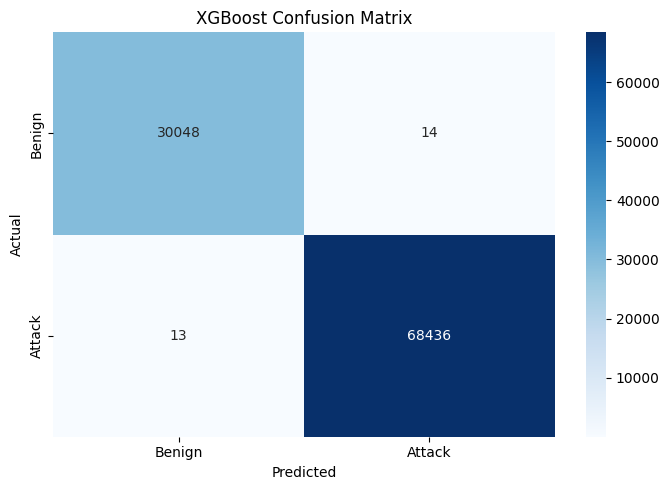

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

xgb_cm = confusion_matrix(y_test, xgb_y_holdout_pred)

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
axes.set_title('XGBoost Confusion Matrix')
axes.set_ylabel('Actual'); axes.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150)
plt.show()

In [29]:
import json
import joblib

with open('xgb_best_params.json', 'w') as f:
    json.dump(xgb_best_params, f, indent=4)
print("xgb_best_params.json saved.")

joblib.dump(xgb_model, 'xgb_final.pkl')
print("xgb_final.pkl saved.")

with open('model_columns.json', 'w') as f:
    json.dump(X_train.columns.tolist(), f, indent=4)
print("model_columns.json saved.")

xgb_best_params.json saved.
xgb_final.pkl saved.
model_columns.json saved.
